# SAXS spectra with pysnow

Here we can take a look at how to use pySNOW to compute Small Angle X-Ray Scattering spectra of finite systems.  
We can employ Debye's formula - spherically averaged - for the scattered intensity at given exchanged momentum **intensity**.

$$ I(q) = \sum_{i,j} f_i(q) f^*_j(q) ~\text{sinc}(qr_{ij}) $$ 
Where
 - $i,j$ run over the indices of atoms 
 - $f(q)$ are the atomic form factors
 - $r_{ij}$ is the distance from atom $i$ to atom $j$

With some manipulation, the above formula becomes:

$$ I(q) = \int f_i(q) f^*_j(q) ~\text{PDDF}(r)~\text{sinc}(qr) $$

In [1]:
from snow.descriptors import saxs
from snow.io.xyz import read_xyz_movie_extended,read_xyz
from snow.descriptors.utils import distance_matrix
import os
import inspect
import numpy as np
from matplotlib import pyplot as plt

If structures are small enough, we can use the full Debye formula. Note that this has scaling $O(N^2)$.  
We can achieve this exploiting the efficient `distance_matrix` function.  
If structures are very large - or we wish to efficiently perform statisctical averages - it becomes very convenient to employ the continuous formulation.  
This is done using the `iq_from_pddf` function. The accuracy and speed of this method will depend on:
 - The maximum distance considered (larger is accurate but slower)
 - The width of the distance bins in PDDF ( smaller is accurate but slower)

In [ ]:
from snow.descriptors import saxs
from snow.io.xyz import read_xyz_movie_extended,read_xyz
import os
import inspect
from pathlib import Path

base=Path.cwd()
#We load a small structure
species,coords = read_xyz(base/"tutorial_structures/Au13_ih.xyz")
#We compute the distance matrix
dist_mat,dist_max,_ = distance_matrix(coords)
#We use it to compute scattering
intensities=[]
qs = np.logspace(-1,0.5,200)
intensities = [saxs.iq_from_dist_mat(species,q ,dist_mat=dist_mat) for q in qs]

plt.plot(qs,intensities)
plt.xscale("log")
plt.yscale("log")
plt.title("Au13")
plt.xlabel(r"Exchanged momentum [$\AA^{-1}$]")
plt.ylabel("Int")
plt.show()

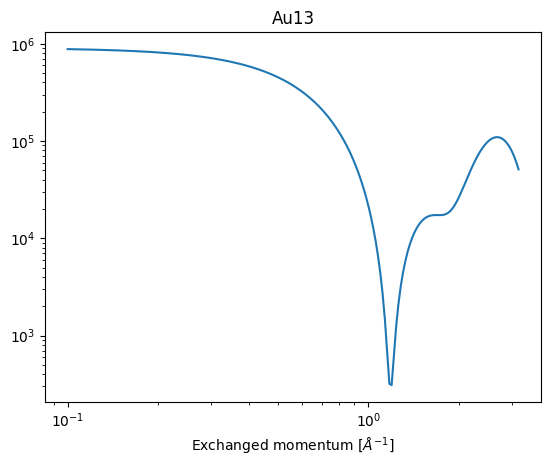

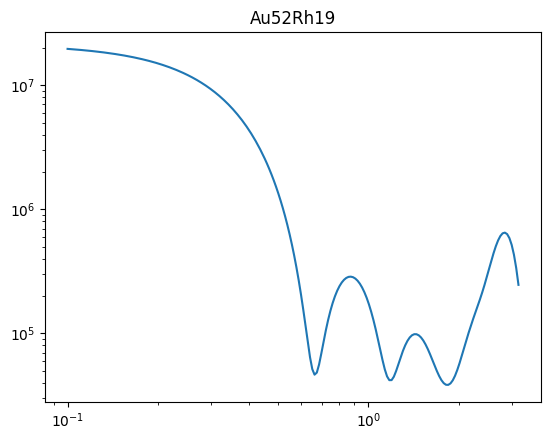

In [16]:
#We load a bimetallic structure
species,coords = read_xyz(base/"tutorial_structures/Au52Rh19.xyz")

#We compute the distance matrix
dist_mat,dist_max,_ = distance_matrix(coords)
#We use it to compute scattering
intensities=[]
qs = np.logspace(-1,0.5,200)
intensities = [saxs.iq_from_dist_mat(species,q ,dist_mat=dist_mat) for q in qs]

plt.plot(qs,intensities)
plt.title("Au52Rh19")
plt.xscale("log")
plt.yscale("log")

plt.show()